In [1]:
"""
08_QVM_v221_flat_vectorized_strategy.py
=======================================

Thin orchestration runner for QVM momentum strategy using v2.2.1 flat vectorized engine.

Phases:
1) Config + validation
2) Universe + factors (engine)
3) Holdings (top-N)
4) Prices + benchmark load
5) Portfolio returns (no-risk) + (with-risk)
6) Tearsheet(s) and artifacts

Run:
  python production/tests/phase31_add_fscore/08_QVM_v221_flat_vectorized_strategy.py \
    --config /home/raymond/Documents/Projects/factor-investing-public/production/config/strategy_config_v2_0_1_simple.yml
"""

'\n08_QVM_v221_flat_vectorized_strategy.py\n=======================================\n\nThin orchestration runner for QVM momentum strategy using v2.2.1 flat vectorized engine.\n\nPhases:\n1) Config + validation\n2) Universe + factors (engine)\n3) Holdings (top-N)\n4) Prices + benchmark load\n5) Portfolio returns (no-risk) + (with-risk)\n6) Tearsheet(s) and artifacts\n\nRun:\n  python production/tests/phase31_add_fscore/08_QVM_v221_flat_vectorized_strategy.py     --config /home/raymond/Documents/Projects/factor-investing-public/production/config/strategy_config_v2_0_1_simple.yml\n'

In [2]:
from __future__ import annotations

In [3]:
import argparse
import hashlib
import json
import logging
import os
from pathlib import Path
from typing import Dict, List, Tuple

In [4]:
import numpy as np
import pandas as pd

In [5]:
import sys
# Bootstrap sys.path so this script and its jupytext notebook can import the project packages
try:
    THIS_FILE = Path(__file__).resolve()
    search_roots = [THIS_FILE] + list(THIS_FILE.parents)
except NameError:
    # __file__ is not defined in notebooks; fall back to CWD search
    cwd = Path.cwd().resolve()
    search_roots = [cwd] + list(cwd.parents)

In [6]:
# Find project root that contains the 'production' package
project_root = None
for candidate in search_roots:
    if (candidate / 'production' / '__init__.py').exists():
        project_root = candidate
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

In [7]:
# Ensure local 'scripts' directory is importable without hardcoding absolute paths
scripts_dir_candidates = []
if 'THIS_FILE' in globals():
    scripts_dir_candidates.append((THIS_FILE.parent / 'scripts'))
if project_root is not None:
    scripts_dir_candidates.append(project_root / 'production' / 'tests' / 'phase31_add_fscore' / 'scripts')

In [8]:
for scripts_dir in scripts_dir_candidates:
    if scripts_dir.exists() and str(scripts_dir) not in sys.path:
        sys.path.insert(0, str(scripts_dir))

In [9]:
from production.engine.qvm_engine_v2_2_1_flat import QVMEngineV221Flat
from production.database.connection import DatabaseManager
from production.backtester.core import (
    BacktestConfig,
    build_daily_price_matrix,
    first_trading_day_calendar,
    run_daily_pnl,
)
from production.risk.overlay import drawdown_to_cash_allocation
from production.engine.qvm_engine_v2_2_1_flat_vectorized import install_vectorized_fscore_221
from sqlalchemy import text

In [10]:
# 07_ utilities consolidated under scripts
from production.scripts.configuration_manager import (
    load_strategy_config,
    load_backtest_config,
    validate_version_compatibility,
)
from production.scripts.validation_manager import (
    validate_strategy_config,
)
from production.scripts.tearsheet_generator import (
    calculate_performance_metrics,
    generate_comprehensive_tearsheet,
    generate_comparison_tearsheet,
)

In [11]:
def _setup_logger() -> logging.Logger:
    class _DedupFilter(logging.Filter):
        def __init__(self):
            super().__init__()
            self._last_message = None

        def filter(self, record: logging.LogRecord) -> bool:
            msg = record.getMessage()
            if msg == self._last_message:
                return False
            self._last_message = msg
            return True

    logger = logging.getLogger("QVM_v221_runner")
    if not logger.handlers:
        logger.setLevel(logging.INFO)
        ch = logging.StreamHandler()
        ch.setFormatter(logging.Formatter("%(asctime)s - %(levelname)s - %(message)s"))
        ch.addFilter(_DedupFilter())
        logger.addHandler(ch)
    # Also add dedup filter to root to reduce duplicate engine logs
    root = logging.getLogger()
    if not any(isinstance(f, _DedupFilter) for f in root.filters):
        root.addFilter(_DedupFilter())
    return logger

In [12]:
def _hash_config(cfg: Dict) -> str:
    norm = json.dumps(cfg, sort_keys=True).encode("utf-8")
    return hashlib.sha256(norm).hexdigest()[:12]

In [13]:
def _ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)

In [14]:
def _select_top_n_holdings(scores: Dict[str, Dict[str, float]], n: int) -> List[str]:
    df = pd.DataFrame.from_dict(scores, orient="index")
    if df.empty or "QVM_Composite" not in df.columns:
        return []
    ranked = df.sort_values("QVM_Composite", ascending=False)
    return ranked.index.tolist()[:n]

In [15]:
def _parse_active_window(backtest_cfg: Dict) -> Tuple[pd.Timestamp, pd.Timestamp]:
    """Support both dict windows {start,end} and string keys into backtest_windows."""
    aw = backtest_cfg.get("active_window", {})
    if isinstance(aw, dict):
        start_date = pd.to_datetime(aw.get("start"))
        end_date = pd.to_datetime(aw.get("end"))
        return start_date, end_date
    windows = backtest_cfg.get("backtest_windows", {})
    if isinstance(aw, str) and aw in windows:
        start_date = pd.to_datetime(windows[aw].get("start"))
        end_date = pd.to_datetime(windows[aw].get("end"))
        return start_date, end_date
    # Fallback: first available window
    if windows:
        key = sorted(windows.keys())[0]
        start_date = pd.to_datetime(windows[key].get("start"))
        end_date = pd.to_datetime(windows[key].get("end"))
        return start_date, end_date
    raise ValueError("active_window not found and no backtest_windows available")

In [16]:
def _previous_quarter_end(d: pd.Timestamp) -> pd.Timestamp:
    """Return the previous quarter-end date for a given date's month."""
    y = d.year
    m = d.month
    if m <= 3:
        return pd.Timestamp(year=y - 1, month=12, day=31)
    if m <= 6:
        return pd.Timestamp(year=y, month=3, day=31)
    if m <= 9:
        return pd.Timestamp(year=y, month=6, day=30)
    return pd.Timestamp(year=y, month=9, day=30)

In [17]:
def _first_trading_on_or_after(date_like: pd.Timestamp, trading_index: pd.DatetimeIndex) -> pd.Timestamp:
    pos = trading_index.searchsorted(date_like, side="left")
    if pos >= len(trading_index):
        return pd.NaT
    return trading_index[pos]

In [18]:
def _build_rebalance_calendar(
    benchmark_prices: pd.Series,
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
    backtest_cfg: Dict,
) -> List[pd.Timestamp]:
    """Construct monthly rebalance dates with support for different anchors.

    Modes (by precedence):
      - If backtest_cfg['fundamentals']['reporting_lag_days'] is set: use 'quarter_lag' with that lag
      - Else if backtest_cfg['rebalance']['anchor'] in {'first_trading_day','mid_month','quarter_lag'}
        and optional 'lag_days': use specified
      - Else default to 'first_trading_day'
    """
    trading_index = benchmark_prices.index
    # Determine mode and lag
    mode = "first_trading_day"
    lag_days = None
    fundamentals_cfg = backtest_cfg.get("fundamentals", {})
    if isinstance(fundamentals_cfg, dict) and isinstance(fundamentals_cfg.get("reporting_lag_days"), (int, float)):
        mode = "quarter_lag"
        lag_days = int(fundamentals_cfg["reporting_lag_days"])
    else:
        rebalance_cfg = backtest_cfg.get("rebalance", {})
        if isinstance(rebalance_cfg, dict):
            mode = rebalance_cfg.get("anchor", mode)
            if isinstance(rebalance_cfg.get("lag_days"), (int, float)):
                lag_days = int(rebalance_cfg["lag_days"])

    # Generate per-month anchor dates within the requested window
    months = pd.period_range(start=start_date.to_period("M"), end=end_date.to_period("M"), freq="M")
    anchors: List[pd.Timestamp] = []
    for p in months:
        month_start = p.to_timestamp("D")
        if mode == "mid_month":
            candidate = pd.Timestamp(year=month_start.year, month=month_start.month, day=15)
            anchor = _first_trading_on_or_after(candidate, trading_index)
        elif mode == "quarter_lag":
            q_end = _previous_quarter_end(month_start)
            eff_lag = lag_days if lag_days is not None else 60
            candidate = q_end + pd.Timedelta(days=eff_lag)
            anchor = _first_trading_on_or_after(candidate, trading_index)
        else:  # first_trading_day
            candidate = month_start
            anchor = _first_trading_on_or_after(candidate, trading_index)
        if pd.isna(anchor):
            continue
        if anchor < start_date or anchor > end_date:
            continue
        anchors.append(anchor)
    # Deduplicate and sort
    anchors = sorted(pd.to_datetime(list(dict.fromkeys(anchors))))
    return anchors

In [19]:
def main():
    logger = _setup_logger()
    parser = argparse.ArgumentParser()
    parser.add_argument("--config", type=str, required=False, default=None)
    parser.add_argument("--window", type=str, required=False, help="YYYY-MM-DD:YYYY-MM-DD override")
    args = parser.parse_args()

    # Phase 1: Config + validation
    strategy_cfg = load_strategy_config(args.config)
    backtest_cfg = load_backtest_config(args.config)
    validate_version_compatibility(strategy_cfg, backtest_cfg)
    validate_strategy_config(strategy_cfg, logger)

    if args.window:
        start_s, end_s = args.window.split(":")
        backtest_cfg["active_window"] = {"start": start_s, "end": end_s}

    run_id = _hash_config({"strategy": strategy_cfg, "backtest": backtest_cfg})
    artifacts_dir = Path("artifacts/qvm_v221_flat_vectorized") / run_id
    _ensure_dir(artifacts_dir)
    # Persist config snapshot for lineage
    with open(artifacts_dir / 'strategy_config.json', 'w', encoding='utf-8') as f:
        json.dump(strategy_cfg, f, indent=2, sort_keys=True)
    with open(artifacts_dir / 'backtest_config.json', 'w', encoding='utf-8') as f:
        json.dump(backtest_cfg, f, indent=2, sort_keys=True)

    # DB engine
    db = DatabaseManager()
    db_engine = db.get_engine()

    # Strategy parameters
    portfolio_size = strategy_cfg.get("strategy", {}).get("portfolio", {}).get("portfolio_size", 20)
    tc_bps = backtest_cfg.get("transaction_cost_bps", 10.0)
    start_date, end_date = _parse_active_window(backtest_cfg)

    # Phase 2-3: Universe, factors, holdings per monthly rebalance date
    engine = QVMEngineV221Flat()
    # Enable vectorized F-Score path (v2.2.1) via config flag (default ON)
    try:
        use_vec = bool(strategy_cfg.get("f_score", {}).get("use_vectorized_fscore_221", True))
        engine.use_vectorized_fscore_221 = use_vec
        if use_vec:
            install_vectorized_fscore_221(engine)
            logger.info("Feature Flag: USE_VECTORIZED_F_SCORE_221=ON — vectorized F-Score installed (runner)")
        else:
            logger.info("Feature Flag: USE_VECTORIZED_F_SCORE_221=OFF — using non-vectorized F-Score path")
    except Exception as e:
        logger.warning(f"Vectorized F-Score enablement failed; falling back to non-vectorized path: {e}")
    all_holdings: Dict[pd.Timestamp, List[str]] = {}
    monthly_dates: List[pd.Timestamp] = []

    # Build a trading calendar from benchmark to anchor dates (parameterized queries with fallbacks)
    def _load_benchmark_series(engine, start_dt: pd.Timestamp, end_dt: pd.Timestamp) -> Tuple[pd.Series, pd.Series]:
        # Try etf_history first (date, close)
        try:
            q1 = text("""
                SELECT date AS date, close AS close_price
                FROM etf_history
                WHERE ticker = 'VNINDEX' AND date BETWEEN :start AND :end
                ORDER BY date
            """)
            df1 = pd.read_sql(q1, engine, params={"start": start_dt, "end": end_dt})
            if not df1.empty:
                df1["date"] = pd.to_datetime(df1["date"]) 
                close = df1.set_index("date")["close_price"].sort_index()
                return close, close.pct_change().dropna()
        except Exception:
            pass

        # Fallback to vcsc_daily_data_complete (trading_date, close_price)
        q2 = text("""
            SELECT trading_date AS date, close_price AS close_price
            FROM vcsc_daily_data_complete
            WHERE ticker = 'VNINDEX' AND trading_date BETWEEN :start AND :end
            ORDER BY trading_date
        """)
        df2 = pd.read_sql(q2, engine, params={"start": start_dt, "end": end_dt})
        if df2.empty:
            return pd.Series(dtype=float), pd.Series(dtype=float)
        df2["date"] = pd.to_datetime(df2["date"]) 
        close = df2.set_index("date")["close_price"].sort_index()
        return close, close.pct_change().dropna()

    benchmark_prices, benchmark_returns = _load_benchmark_series(db_engine, start_date, end_date)
    if benchmark_prices.empty:
        raise RuntimeError("Benchmark data not found; cannot proceed")

    # Rebalance calendar with fundamentals-aware options
    monthly_dates = _build_rebalance_calendar(
        benchmark_prices=benchmark_prices,
        start_date=start_date,
        end_date=end_date,
        backtest_cfg=backtest_cfg,
    )

    diag_rows = []
    for reb_date in monthly_dates:
        # Universe selection from DB
        from production.universe.constructors import get_liquid_universe
        universe = get_liquid_universe(reb_date, db_engine)
        if not universe:
            logger.warning(f"Empty universe on {reb_date.date()} - skipping")
            diag_rows.append({
                "date": pd.Timestamp(reb_date),
                "universe_size": 0,
                "had_scores": False,
                "holdings_size": 0,
            })
            continue

        # Engine factor computation and composite
        scores = engine.calculate_qvm_composite_fixed(reb_date, universe)
        if not scores:
            logger.warning(f"No scores on {reb_date.date()} - skipping")
            diag_rows.append({
                "date": pd.Timestamp(reb_date),
                "universe_size": len(universe) if universe else 0,
                "had_scores": False,
                "holdings_size": 0,
            })
            continue

        holdings = _select_top_n_holdings(scores, portfolio_size)
        if not holdings:
            logger.warning(f"No holdings on {reb_date.date()} - skipping")
            diag_rows.append({
                "date": pd.Timestamp(reb_date),
                "universe_size": len(universe) if universe else 0,
                "had_scores": True,
                "holdings_size": 0,
            })
            continue
        all_holdings[reb_date] = holdings
        diag_rows.append({
            "date": pd.Timestamp(reb_date),
            "universe_size": len(universe) if universe else 0,
            "had_scores": True,
            "holdings_size": len(holdings),
        })

    # (moved) Save holdings artifact after calendar alignment below
    if not all_holdings:
        raise RuntimeError("No holdings generated in the window")

    # Phase 4: Prices + benchmark
    unique_tickers = sorted({t for lst in all_holdings.values() for t in lst})
    price_matrix = build_daily_price_matrix(db_engine, unique_tickers, start_date, end_date, logger)

    # Align calendar to available prices and prune holdings to calendar dates
    cal = first_trading_day_calendar(price_matrix)
    cal = [d for d in cal if d in all_holdings]
    if not cal:
        raise RuntimeError("No valid rebalance dates after alignment")
    all_holdings = {d: all_holdings[d] for d in cal}

    # Save holdings artifact (calendar-aligned)
    h_rows = []
    for d, lst in all_holdings.items():
        for t in lst:
            h_rows.append({"date": pd.Timestamp(d), "ticker": t})
    pd.DataFrame(h_rows).to_csv(artifacts_dir / 'monthly_holdings.csv', index=False)

    # Save diagnostics
    if diag_rows:
        pd.DataFrame(diag_rows).to_csv(artifacts_dir / 'diagnostics.csv', index=False)

    # Phase 5: Daily PnL with and without risk overlay
    bt_cfg = BacktestConfig(transaction_cost_bps=tc_bps, portfolio_size=portfolio_size)

    def overlay_fn(bench_prices: pd.Series, current_date: pd.Timestamp) -> float:
        rules = strategy_cfg.get("risk_management", {}).get("cash_allocation", {})
        return drawdown_to_cash_allocation(bench_prices, current_date, rules)

    # No-risk path
    no_risk_returns, no_risk_equity, _ = run_daily_pnl(
        daily_prices=price_matrix,
        monthly_rebalance_dates=cal,
        monthly_holdings=all_holdings,
        backtest_config=bt_cfg,
        risk_overlay_fn=None,
        benchmark_prices=benchmark_prices,
        logger=logger,
    )
    # With-risk path
    with_risk_returns, with_risk_equity, cash_df = run_daily_pnl(
        daily_prices=price_matrix,
        monthly_rebalance_dates=cal,
        monthly_holdings=all_holdings,
        backtest_config=bt_cfg,
        risk_overlay_fn=overlay_fn,
        benchmark_prices=benchmark_prices,
        logger=logger,
    )

    # Phase 6: Tearsheet(s)
    artifacts = {
        "no_risk_returns.csv": no_risk_returns,
        "with_risk_returns.csv": with_risk_returns,
        "with_risk_cash.csv": cash_df["cash_allocation"],
        "benchmark_returns.csv": benchmark_returns,
    }
    for name, series in artifacts.items():
        series.to_csv(artifacts_dir / name, header=True)

    # Prepare cash allocations for tearsheet consumption
    cash_allocations_df = cash_df.copy()
    cash_allocations_df = cash_allocations_df.reset_index().rename(columns={cash_allocations_df.index.name or 'index': 'date'})
    cash_allocations_df['date'] = pd.to_datetime(cash_allocations_df['date'])
    if 'cash_allocation' in cash_allocations_df.columns:
        cash_allocations_df['cash_percentage'] = cash_allocations_df['cash_allocation'] * 100.0

    # Generate comparison tearsheet (with-risk vs no-risk vs benchmark)
    generate_comparison_tearsheet(
        with_risk_returns,
        no_risk_returns,
        benchmark_returns,
        cash_allocations_df,
        strategy_cfg,
    )

    logger.info(f"Artifacts saved under {artifacts_dir}")

2025-08-22 23:18:38,073 - INFO - ✅ Factor weights validation passed: 1.000000
2025-08-22 23:18:38,074 - INFO -    Weights: {'quality': 0.25, 'value': 0.25, 'momentum': 0.25, 'defensive': 0.25}
2025-08-22 23:18:38,074 - INFO - ✅ Strategy configuration validation completed successfully
2025-08-22 23:18:38,077 - production.database.connection - INFO - Database configuration loaded from /home/raymond/Documents/Projects/factor-investing-public/config/database.yml
2025-08-22 23:18:38,077 - production.database.connection - INFO - DatabaseManager initialized for environment: production
2025-08-22 23:18:38,090 - production.database.connection - INFO - SQLAlchemy engine created successfully
2025-08-22 23:18:38,092 - QVMEngineV201Flat - INFO - Initializing QVM Engine v2.0.1 Flat Methodology
2025-08-22 23:18:38,146 - QVMEngineV201Flat - INFO - Enhanced configurations loaded successfully
2025-08-22 23:18:38,147 - QVMEngineV201Flat - INFO - Flat composite weights loaded successfully
2025-08-22 23:18

✅ Strategy configuration loaded from /home/raymond/Documents/Projects/factor-investing-public/config/strategy_config_v2_0_1_simple.yml
✅ Backtest configuration loaded from /home/raymond/Documents/Projects/factor-investing-public/production/config/backtest_config.yml
🔄 Merging backtest configuration with strategy settings...
✅ Portfolio size updated to 20 stocks
⚠️ Warning: No drawdown thresholds found in backtest config
   Please add drawdown_thresholds to your backtest_config.yml:
   risk_overlay:
     drawdown_thresholds:
       drawdown_5: 0.20
       drawdown_10: 0.40
       drawdown_15: 0.60
       drawdown_20: 0.80
       drawdown_25: 0.90
✅ Rebalancing frequency set to monthly
✅ Backtest configuration merged successfully
✅ Version compatibility validation completed


FATAL: Market data empty for 2016Q1
   Universe: ['VNM', 'MSN', 'FPT', 'SBT', 'VIC', 'GEX', 'HHS', 'HAG', 'SSI', 'CII', 'HPG', 'KDC', 'VCB', 'DLG', 'MBB', 'FIT', 'TIG', 'SCR', 'GMD', 'MWG', 'SHI', 'OGC', 'HQC', 'SHB', 'DPM', 'BID', 'HSG', 'PVD', 'TTF', 'BVH', 'GAS', 'PGD', 'DXG', 'ITA', 'HNG', 'TCM', 'ASM', 'BCG', 'PVS', 'TSC', 'KBC', 'NT2', 'BMP', 'LAS', 'CTG', 'KLF', 'VSC', 'VCF', 'VCG', 'SAM', 'MHC', 'PDR', 'DBC', 'SHN', 'HAH', 'HBC']
   Analysis date: 2016-01-04 00:00:00
   Query: vcsc_daily_data_complete WHERE trading_date=analysis_date
2025-08-22 23:18:47,191 - WARNING - No scores on 2016-01-04 - skipping
Using FALLBACK cross-sectional normalization due to insufficient sector sizes
This is not ideal - consider expanding universe for proper sector-neutral analysis
Using FALLBACK cross-sectional normalization due to insufficient sector sizes
This is not ideal - consider expanding universe for proper sector-neutral analysis
Using FALLBACK cross-sectional normalization due to insuffi


📊 COMPREHENSIVE STRATEGY COMPARISON TEARSHEET

⚙️ CONFIGURATION SUMMARY
----------------------------------------
   Strategy: QVM Simple Factors v2.0.1
   Portfolio Size: 20 stocks
   Starting Capital: 10,000,000,000 VND
   Factor Weights: Q(25.0%) V(25.0%) M(25.0%)

🔍 PERFORMANCE METRICS COMPARISON
------------------------------------------------------------
❌ ERROR calculating benchmark metrics: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 2369 and the array at index 1 has size 2350
✅ Performance metrics calculated successfully:
   Annualized Return: 0.0634
   Max Drawdown: -0.3151
   Sharpe Ratio: 0.5012

✅ WITH Risk Management:
   Annualized Return: 6.34%
   Volatility: 12.65%
   Sharpe Ratio: 0.501
   Max Drawdown: -31.51%
   Calmar Ratio: 0.201
   Information Ratio: 0.000
   Beta: 0.000
❌ ERROR calculating benchmark metrics: all the input array dimensions except for the concatenation axi

ValueError: Invalid frequency: YE

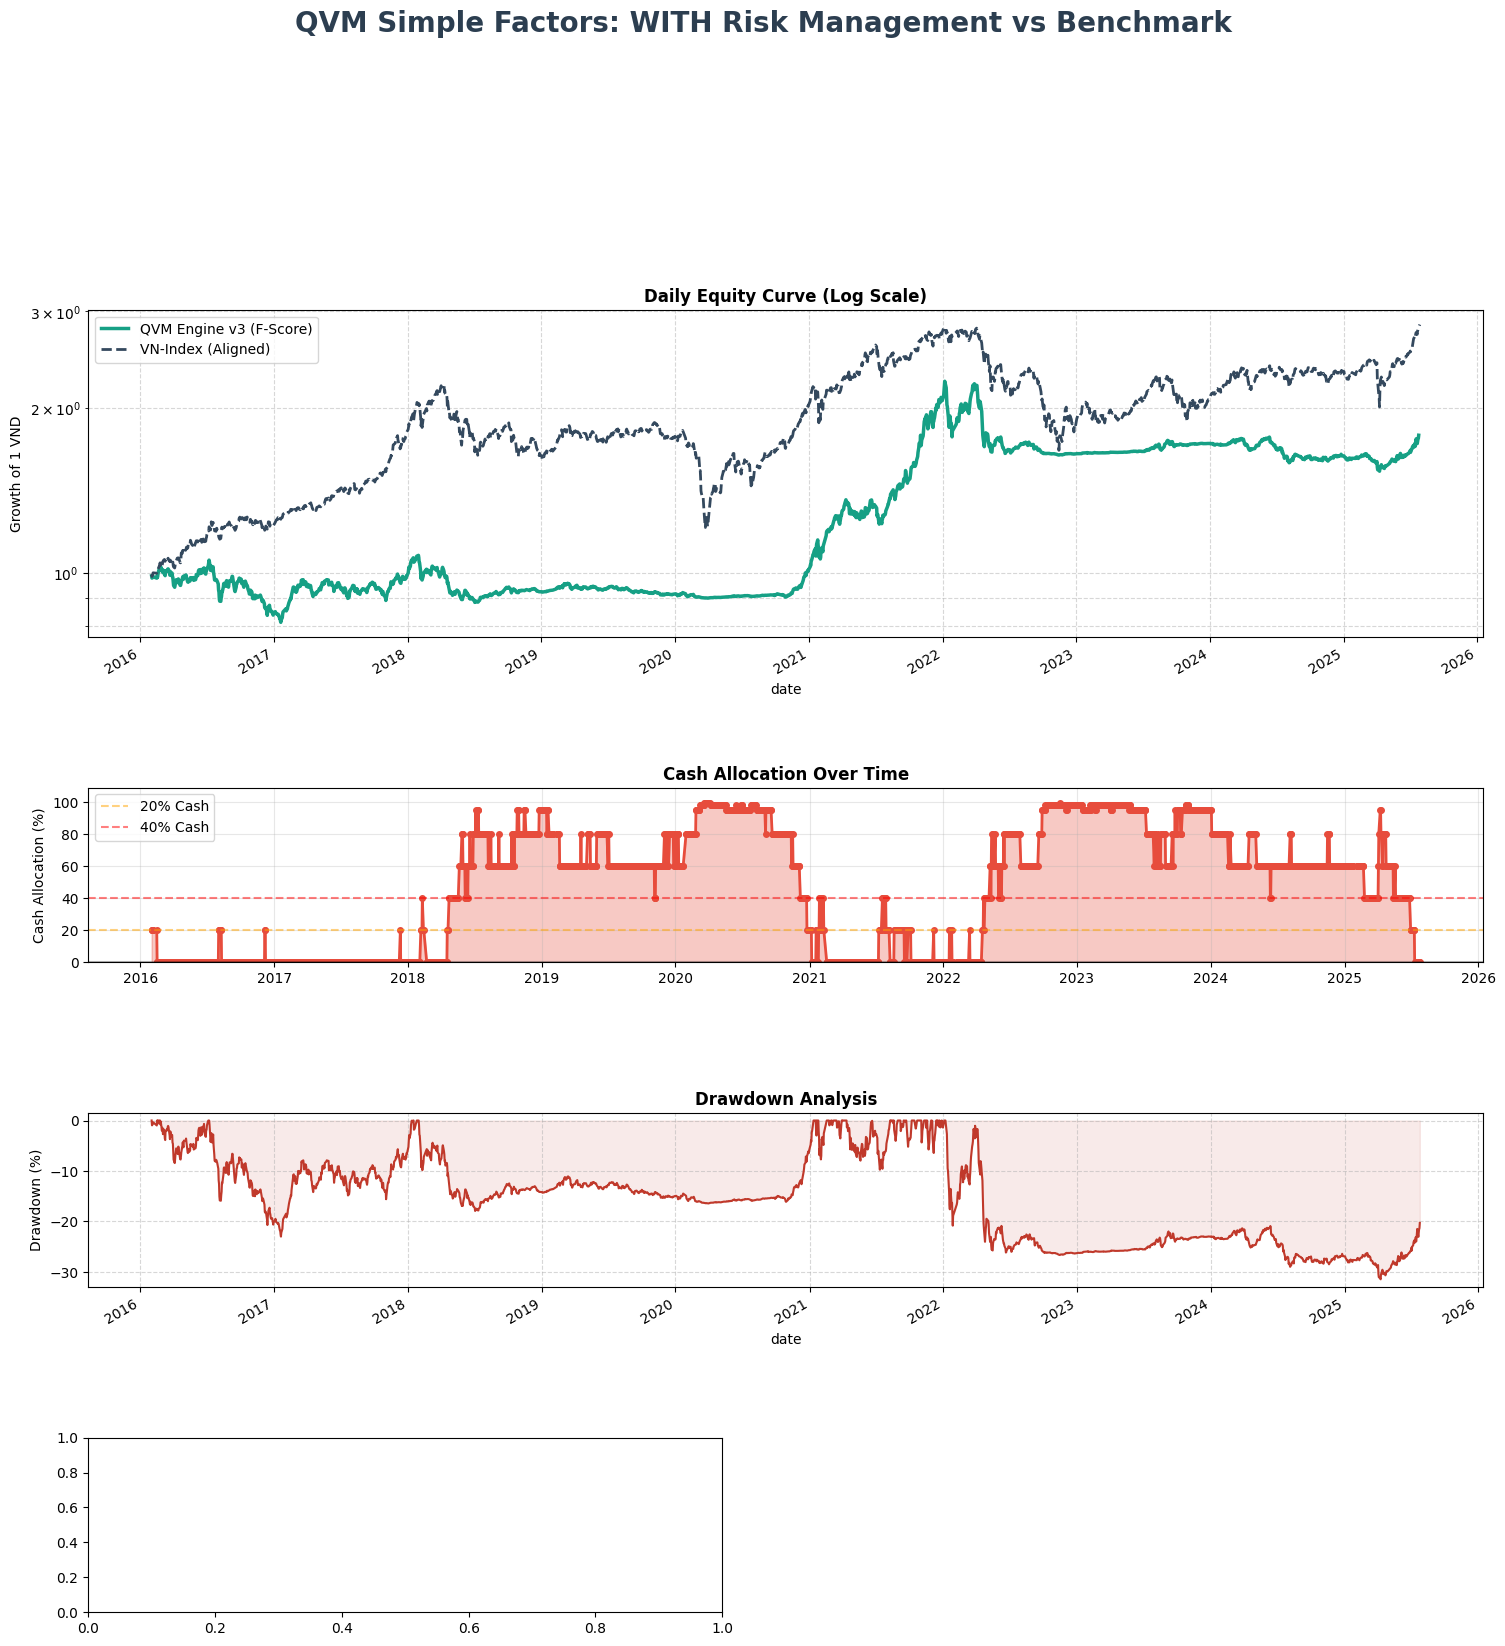

In [20]:
if __name__ == "__main__":
    # Avoid passing IPython/Jupyter argv (e.g., --f=...) into argparse when running in a notebook
    if 'ipykernel' in sys.modules:
        _argv_backup = sys.argv[:]
        sys.argv = [sys.argv[0]]
        try:
            main()
        finally:
            sys.argv = _argv_backup
    else:
        main()